# Individual-dataset ensemble analysis

This notebook tests whether any ensemble strategy improves UdonPred performance on individual evaluation datasets. `pdbflex` is excluded throughout because prior notebooks show that it measures structural flexibility rather than intrinsic disorder directly.

Two baselines are used:

- `validation_selected_single_head`: deployable UdonPred baseline selected from validation performance.
- `best_individual_test_oracle`: non-deployable reference showing the best individual UdonPred head on the test set.

The analysis uses existing result CSVs only; it does not regenerate predictions.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 40)

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "results").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root containing results/ and notebooks/.")

ROOT = find_repo_root(Path.cwd())
RESULTS = ROOT / "results"
OUT_DIR = RESULTS / "ensembles_individual"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOL = 1e-6
TARGET_METRICS = ["trizod", "chezod", "softdis", "atlas", "plddt", "disprot (AP)", "disprot (AUROC)"]
METRIC_TO_DATASET = {
    "trizod": "trizod",
    "chezod": "chezod",
    "softdis": "softdis",
    "atlas": "atlas",
    "plddt": "plddt",
    "disprot (AP)": "disprot",
    "disprot (AUROC)": "disprot",
}
COLUMN_RENAME = {
    "disprot\n(AP)": "disprot (AP)",
    "disprot\r\n(AP)": "disprot (AP)",
    "disprot\n(AUROC)": "disprot (AUROC)",
    "disprot\r\n(AUROC)": "disprot (AUROC)",
}

print(f"Repository root: {ROOT}")
print(f"Notebook outputs: {OUT_DIR}")

Repository root: D:\Protein_Prediction
Notebook outputs: D:\Protein_Prediction\results\ensembles_individual


## Input audit

Most inputs are expected to exist. The SETH/external table and older ensemble folders are treated as source-specific evidence because some result folders were produced by different notebook revisions.

In [2]:
INPUTS = {
    "udonpred_matrix": RESULTS / "udonpred_matrix" / "matrix.csv",
    "legacy_ensembles": RESULTS / "ensembles" / "ensemble_matrix.csv",
    "ceiling_selected_ensembles": RESULTS / "ensembles_ceiling_selected_head" / "ensemble_matrix.csv",
    "mmseqs_strategy": RESULTS / "mmseqs_ceiling_aware_weighting" / "strategy_matrix.csv",
    "combined_mmseqs_strategy": RESULTS / "mmseqs_ceiling_aware_weighting" / "combined_previous_and_mmseqs_strategy_matrix.csv",
    "seth_scores_long": RESULTS / "seth_ensemble" / "comparison_scores_long.csv",
    "seth_delta_matrix": RESULTS / "seth_ensemble" / "comparison_delta_matrix.csv",
}

input_audit = pd.DataFrame(
    [
        {"source": name, "path": str(path.relative_to(ROOT)), "exists": path.exists(), "bytes": path.stat().st_size if path.exists() else np.nan}
        for name, path in INPUTS.items()
    ]
)
input_audit.to_csv(OUT_DIR / "input_audit.csv", index=False)
display(input_audit)

missing_required = input_audit.loc[
    input_audit["source"].isin(["udonpred_matrix", "combined_mmseqs_strategy"]) & ~input_audit["exists"],
    "source",
].tolist()
if missing_required:
    raise FileNotFoundError(f"Missing required inputs: {missing_required}")

missing_optional = input_audit.loc[~input_audit["exists"], "source"].tolist()
if missing_optional:
    warnings.warn(f"Optional sources missing and will be skipped: {missing_optional}")

,source,path,exists,bytes
0,udonpred_matrix,results\udonpred_matrix\matrix.csv,True,653
1,legacy_ensembles,results\ensembles\ensemble_matrix.csv,True,1566
2,ceiling_selected_ensembles,results\ensembles_ceiling_selected_head\ensemb...,True,1750
3,mmseqs_strategy,results\mmseqs_ceiling_aware_weighting\strateg...,True,1518
4,combined_mmseqs_strategy,results\mmseqs_ceiling_aware_weighting\combine...,True,2631
5,seth_scores_long,results\seth_ensemble\comparison_scores_long.csv,True,10380
6,seth_delta_matrix,results\seth_ensemble\comparison_delta_matrix.csv,True,1266


## Loading helpers

In [3]:
def normalize_metric_name(value, dataset=None):
    text = str(value).replace("\r", " ").replace("\n", " ").strip()
    compact = " ".join(text.split())
    lower = compact.lower()
    if lower in {"trizod", "chezod", "softdis", "atlas", "plddt"}:
        return lower
    if "disprot" in lower and "auroc" in lower:
        return "disprot (AUROC)"
    if "disprot" in lower and "ap" in lower:
        return "disprot (AP)"
    if str(dataset).lower() == "disprot" and lower in {"ap", "average_precision", "average precision"}:
        return "disprot (AP)"
    if str(dataset).lower() == "disprot" and lower in {"auroc", "roc_auc", "roc auc"}:
        return "disprot (AUROC)"
    return compact

def normalize_matrix_columns(df: pd.DataFrame) -> pd.DataFrame:
    renamed = {}
    for column in df.columns:
        renamed[column] = normalize_metric_name(column)
    renamed.update({old: new for old, new in COLUMN_RENAME.items() if old in df.columns})
    return df.rename(columns=renamed)

def load_strategy_matrix(path: Path, method_family: str, source: str, method_col: str = "strategy") -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df = normalize_matrix_columns(df)
    if method_col not in df.columns:
        raise KeyError(f"{path} does not contain expected method column {method_col!r}; columns={list(df.columns)}")
    df = df.rename(columns={method_col: "method"})
    df["method"] = df["method"].astype(str)
    df = df[df["method"].str.lower() != "pdbflex"].copy()
    value_cols = [column for column in TARGET_METRICS if column in df.columns]
    if not value_cols:
        raise ValueError(f"No target metric columns found in {path}")
    long = df.melt(id_vars=["method"], value_vars=value_cols, var_name="metric", value_name="score")
    long["score"] = pd.to_numeric(long["score"], errors="coerce")
    long = long.dropna(subset=["score"])
    long["dataset"] = long["metric"].map(METRIC_TO_DATASET)
    long = long[long["dataset"].ne("pdbflex")].copy()
    long["method_family"] = method_family
    long["source"] = source
    long["method_label"] = long["source"] + " | " + long["method"]
    return long[["source", "method_family", "method", "method_label", "dataset", "metric", "score"]]

def load_seth_scores(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df = df[df["scenario"].eq("full")].copy()
    df["dataset"] = df["dataset"].astype(str).str.lower()
    df = df[df["dataset"].ne("pdbflex")].copy()
    df["metric"] = [normalize_metric_name(metric, dataset) for metric, dataset in zip(df["metric"], df["dataset"])]
    df = df[df["metric"].isin(TARGET_METRICS)].copy()
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    df = df.dropna(subset=["score"])
    df["method_family"] = "SETH/external-augmented"
    df["source"] = "seth_full"
    df["method_label"] = df["source"] + " | " + df["method"].astype(str)
    return df[["source", "method_family", "method", "method_label", "dataset", "metric", "score", "n_proteins", "n_residues"]]

## Assemble comparison table

The latest combined MMseqs/ceiling-aware matrix is used as the primary UdonPred baseline source. Older sources are still loaded and plotted, but the baseline consistency audit below makes version differences explicit.

In [4]:
matrix_sources = [
    (INPUTS["legacy_ensembles"], "UdonPred-only", "legacy_ensembles", "strategy"),
    (INPUTS["ceiling_selected_ensembles"], "ceiling-aware", "ceiling_selected", "strategy"),
    (INPUTS["mmseqs_strategy"], "MMseqs/ceiling-aware", "mmseqs_strategy", "strategy"),
    (INPUTS["combined_mmseqs_strategy"], "MMseqs/ceiling-aware", "combined_mmseqs", "strategy"),
]

comparison_parts = [
    load_strategy_matrix(path, family, source, method_col)
    for path, family, source, method_col in matrix_sources
]
comparison_parts.append(load_seth_scores(INPUTS["seth_scores_long"]))

comparison = pd.concat([part for part in comparison_parts if not part.empty], ignore_index=True, sort=False)
comparison["score"] = pd.to_numeric(comparison["score"], errors="coerce")
comparison = comparison.dropna(subset=["score"])

individual_heads = load_strategy_matrix(
    INPUTS["udonpred_matrix"],
    method_family="UdonPred individual heads",
    source="udonpred_matrix",
    method_col="train_dataset",
)
individual_heads.to_csv(OUT_DIR / "individual_head_scores_no_pdbflex.csv", index=False)

assert not comparison["dataset"].eq("pdbflex").any()
assert not comparison["metric"].astype(str).str.contains("pdbflex", case=False, na=False).any()
assert not individual_heads["method"].str.lower().eq("pdbflex").any()

display(comparison.head())
print(f"Loaded {len(comparison):,} method/metric rows from {comparison['source'].nunique()} sources.")

,source,method_family,method,method_label,dataset,metric,score,n_proteins,n_residues
0,legacy_ensembles,UdonPred-only,best_individual_test_oracle,legacy_ensembles | best_individual_test_oracle,trizod,trizod,0.507853,NaN,NaN
1,legacy_ensembles,UdonPred-only,simple_mean_all_heads,legacy_ensembles | simple_mean_all_heads,trizod,trizod,0.454205,NaN,NaN
2,legacy_ensembles,UdonPred-only,validation_selected_single_head,legacy_ensembles | validation_selected_single_...,trizod,trizod,0.507853,NaN,NaN
3,legacy_ensembles,UdonPred-only,global_convex_validation,legacy_ensembles | global_convex_validation,trizod,trizod,0.434461,NaN,NaN
4,legacy_ensembles,UdonPred-only,per_target_convex_validation,legacy_ensembles | per_target_convex_validation,trizod,trizod,0.508480,NaN,NaN


Loaded 329 method/metric rows from 5 sources.


In [5]:
PRIMARY_SOURCE = "combined_mmseqs"

def get_baseline(method_name: str, preferred_source: str = PRIMARY_SOURCE) -> pd.Series:
    rows = comparison[(comparison["source"].eq(preferred_source)) & (comparison["method"].eq(method_name))]
    if rows.empty:
        rows = comparison[comparison["method"].eq(method_name)]
    if rows.empty:
        raise KeyError(f"Could not find baseline method {method_name!r}")
    return rows.drop_duplicates(["metric"], keep="last").set_index("metric")["score"]

validation_baseline = get_baseline("validation_selected_single_head")
oracle_baseline = get_baseline("best_individual_test_oracle")

comparison["validation_selected_score"] = comparison["metric"].map(validation_baseline)
comparison["best_individual_test_oracle_score"] = comparison["metric"].map(oracle_baseline)
comparison["delta_vs_validation_selected"] = comparison["score"] - comparison["validation_selected_score"]
comparison["delta_vs_best_individual_test_oracle"] = comparison["score"] - comparison["best_individual_test_oracle_score"]

def classify_delta(delta: float) -> str:
    if pd.isna(delta):
        return "missing"
    if delta > TOL:
        return "win"
    if delta < -TOL:
        return "loss"
    return "tie"

comparison["vs_validation_selected"] = comparison["delta_vs_validation_selected"].map(classify_delta)
comparison["vs_best_individual_test_oracle"] = comparison["delta_vs_best_individual_test_oracle"].map(classify_delta)

lower_method = comparison["method"].astype(str).str.lower()
baseline_like = (
    lower_method.str.contains("oracle")
    | lower_method.str.contains("validation_selected")
    | lower_method.str.contains("same_dataset_head")
    | lower_method.str.contains("selected_single_head")
    | lower_method.eq("seth")
)
comparison["is_candidate_ensemble"] = ~baseline_like

comparison = comparison.sort_values(["method_family", "source", "method", "metric"]).reset_index(drop=True)
comparison.to_csv(OUT_DIR / "ensemble_individual_tidy_comparison.csv", index=False)
display(comparison.head(20))

,source,method_family,method,method_label,dataset,metric,score,n_proteins,n_residues,validation_selected_score,best_individual_test_oracle_score,delta_vs_validation_selected,delta_vs_best_individual_test_oracle,vs_validation_selected,vs_best_individual_test_oracle,is_candidate_ensemble
0,combined_mmseqs,MMseqs/ceiling-aware,best_individual_test_oracle,combined_mmseqs | best_individual_test_oracle,atlas,atlas,0.708063,NaN,NaN,0.708063,0.708063,0.000000e+00,0.000000e+00,tie,tie,False
1,combined_mmseqs,MMseqs/ceiling-aware,best_individual_test_oracle,combined_mmseqs | best_individual_test_oracle,chezod,chezod,0.707732,NaN,NaN,0.691124,0.707732,1.660862e-02,0.000000e+00,win,tie,False
2,combined_mmseqs,MMseqs/ceiling-aware,best_individual_test_oracle,combined_mmseqs | best_individual_test_oracle,disprot,disprot (AP),0.935162,NaN,NaN,0.935162,0.935162,0.000000e+00,0.000000e+00,tie,tie,False
3,combined_mmseqs,MMseqs/ceiling-aware,best_individual_test_oracle,combined_mmseqs | best_individual_test_oracle,disprot,disprot (AUROC),0.958705,NaN,NaN,0.958705,0.958705,0.000000e+00,0.000000e+00,tie,tie,False
4,combined_mmseqs,MMseqs/ceiling-aware,best_individual_test_oracle,combined_mmseqs | best_individual_test_oracle,plddt,plddt,0.838924,NaN,NaN,0.838924,0.838924,0.000000e+00,0.000000e+00,tie,tie,False
5,combined_mmseqs,MMseqs/ceiling-aware,best_individual_test_oracle,combined_mmseqs | best_individual_test_oracle,softdis,softdis,0.653220,NaN,NaN,0.653220,0.653220,0.000000e+00,0.000000e+00,tie,tie,False
6,combined_mmseqs,MMseqs/ceiling-aware,best_individual_test_oracle,combined_mmseqs | best_individual_test_oracle,trizod,trizod,0.507853,NaN,NaN,0.507853,0.507853,0.000000e+00,0.000000e+00,tie,tie,False
7,combined_mmseqs,MMseqs/ceiling-aware,blended_exact_mmseqs_bio_weighted,combined_mmseqs | blended_exact_mmseqs_bio_wei...,atlas,atlas,0.722034,NaN,NaN,0.708063,0.708063,1.397141e-02,1.397141e-02,win,win,True
8,combined_mmseqs,MMseqs/ceiling-aware,blended_exact_mmseqs_bio_weighted,combined_mmseqs | blended_exact_mmseqs_bio_wei...,chezod,chezod,0.686207,NaN,NaN,0.691124,0.707732,-4.916626e-03,-2.152524e-02,loss,loss,True
9,combined_mmseqs,MMseqs/ceiling-aware,blended_exact_mmseqs_bio_weighted,combined_mmseqs | blended_exact_mmseqs_bio_wei...,disprot,disprot (AP),0.900198,NaN,NaN,0.935162,0.935162,-3.496392e-02,-3.496392e-02,loss,loss,True


## Baseline consistency audit

This table checks whether each source's validation-selected baseline matches the primary baseline. Large differences mean that a source likely came from a different notebook revision or score-processing pass; those rows remain informative but should not be overinterpreted as direct cross-source score differences.

In [6]:
baseline_rows = comparison[comparison["method"].isin(["validation_selected_single_head", "udon_validation_selected_head"])].copy()
baseline_rows["primary_validation_selected_score"] = baseline_rows["metric"].map(validation_baseline)
baseline_rows["delta_vs_primary_validation_baseline"] = baseline_rows["score"] - baseline_rows["primary_validation_selected_score"]
baseline_consistency = (
    baseline_rows.groupby(["source", "method"], as_index=False)
    .agg(
        max_abs_delta_vs_primary=("delta_vs_primary_validation_baseline", lambda values: float(np.nanmax(np.abs(values)))),
        mean_abs_delta_vs_primary=("delta_vs_primary_validation_baseline", lambda values: float(np.nanmean(np.abs(values)))),
        metrics=("metric", "nunique"),
    )
    .sort_values("max_abs_delta_vs_primary", ascending=False)
)
baseline_consistency["baseline_version_note"] = np.where(
    baseline_consistency["max_abs_delta_vs_primary"] > 1e-4,
    "differs from primary baseline",
    "matches primary baseline",
)
baseline_consistency.to_csv(OUT_DIR / "baseline_consistency_audit.csv", index=False)
display(baseline_consistency)

,source,method,max_abs_delta_vs_primary,mean_abs_delta_vs_primary,metrics,baseline_version_note
4,seth_full,udon_validation_selected_head,1.533415e-01,2.190833e-02,7,differs from primary baseline
2,legacy_ensembles,validation_selected_single_head,1.533414e-01,2.190596e-02,7,differs from primary baseline
0,ceiling_selected,validation_selected_single_head,1.298796e-07,5.659712e-08,7,matches primary baseline
1,combined_mmseqs,validation_selected_single_head,0.000000e+00,0.000000e+00,7,matches primary baseline
3,mmseqs_strategy,validation_selected_single_head,0.000000e+00,0.000000e+00,7,matches primary baseline


## Best ensemble per individual dataset

In [7]:
candidate_comparison = comparison[comparison["is_candidate_ensemble"]].copy()

best_idx = candidate_comparison.groupby("metric")["score"].idxmax()
best_by_metric = candidate_comparison.loc[best_idx].copy().sort_values("metric")
best_by_metric["improves_validation_selected"] = best_by_metric["delta_vs_validation_selected"] > TOL
best_by_metric["improves_test_oracle"] = best_by_metric["delta_vs_best_individual_test_oracle"] > TOL
best_by_metric = best_by_metric[
    [
        "dataset",
        "metric",
        "method_family",
        "source",
        "method",
        "score",
        "validation_selected_score",
        "best_individual_test_oracle_score",
        "delta_vs_validation_selected",
        "delta_vs_best_individual_test_oracle",
        "improves_validation_selected",
        "improves_test_oracle",
    ]
]
best_by_metric.to_csv(OUT_DIR / "best_ensemble_by_individual_dataset.csv", index=False)
display(best_by_metric)

,dataset,metric,method_family,source,method,score,validation_selected_score,best_individual_test_oracle_score,delta_vs_validation_selected,delta_vs_best_individual_test_oracle,improves_validation_selected,improves_test_oracle
49,atlas,atlas,MMseqs/ceiling-aware,combined_mmseqs,mmseqs95_ceiling_weighted,0.723943,0.708063,0.708063,0.015880,0.015880,True,True
169,chezod,chezod,SETH/external-augmented,seth_full,fixed_50_50,0.708171,0.691124,0.707732,0.017048,0.000439,True,True
65,disprot,disprot (AP),MMseqs/ceiling-aware,combined_mmseqs,per_target_convex_validation,0.935502,0.935162,0.935162,0.000340,0.000340,True,True
24,disprot,disprot (AUROC),MMseqs/ceiling-aware,combined_mmseqs,exact_ceiling_weighted,0.959158,0.958705,0.958705,0.000453,0.000453,True,True
165,plddt,plddt,SETH/external-augmented,seth_full,augmented_ridge,0.847675,0.838924,0.838924,0.008751,0.008751,True,True
75,softdis,softdis,MMseqs/ceiling-aware,combined_mmseqs,per_target_ridge_stacking_validation,0.657004,0.653220,0.653220,0.003784,0.003784,True,True
174,trizod,trizod,SETH/external-augmented,seth_full,fixed_50_50,0.541460,0.507853,0.507853,0.033607,0.033607,True,True


In [8]:
family_summary = (
    candidate_comparison.groupby("method_family", as_index=False)
    .agg(
        methods=("method_label", "nunique"),
        metric_rows=("metric", "count"),
        mean_delta_vs_validation_selected=("delta_vs_validation_selected", "mean"),
        mean_delta_vs_test_oracle=("delta_vs_best_individual_test_oracle", "mean"),
        wins_vs_validation_selected=("vs_validation_selected", lambda values: int((values == "win").sum())),
        ties_vs_validation_selected=("vs_validation_selected", lambda values: int((values == "tie").sum())),
        losses_vs_validation_selected=("vs_validation_selected", lambda values: int((values == "loss").sum())),
        wins_vs_test_oracle=("vs_best_individual_test_oracle", lambda values: int((values == "win").sum())),
        ties_vs_test_oracle=("vs_best_individual_test_oracle", lambda values: int((values == "tie").sum())),
        losses_vs_test_oracle=("vs_best_individual_test_oracle", lambda values: int((values == "loss").sum())),
    )
    .sort_values("mean_delta_vs_validation_selected", ascending=False)
)
family_summary.to_csv(OUT_DIR / "ensemble_family_win_loss_summary.csv", index=False)
display(family_summary)

,method_family,methods,metric_rows,mean_delta_vs_validation_selected,mean_delta_vs_test_oracle,wins_vs_validation_selected,ties_vs_validation_selected,losses_vs_validation_selected,wins_vs_test_oracle,ties_vs_test_oracle,losses_vs_test_oracle
1,SETH/external-augmented,6,42,-0.033700,-0.036073,15,0,27,13,0,29
0,MMseqs/ceiling-aware,15,105,-0.101070,-0.103443,26,2,77,25,2,78
3,ceiling-aware,6,42,-0.206688,-0.209061,8,2,32,7,2,33
2,UdonPred-only,6,42,-0.218595,-0.220968,6,2,34,5,2,35


## Plots

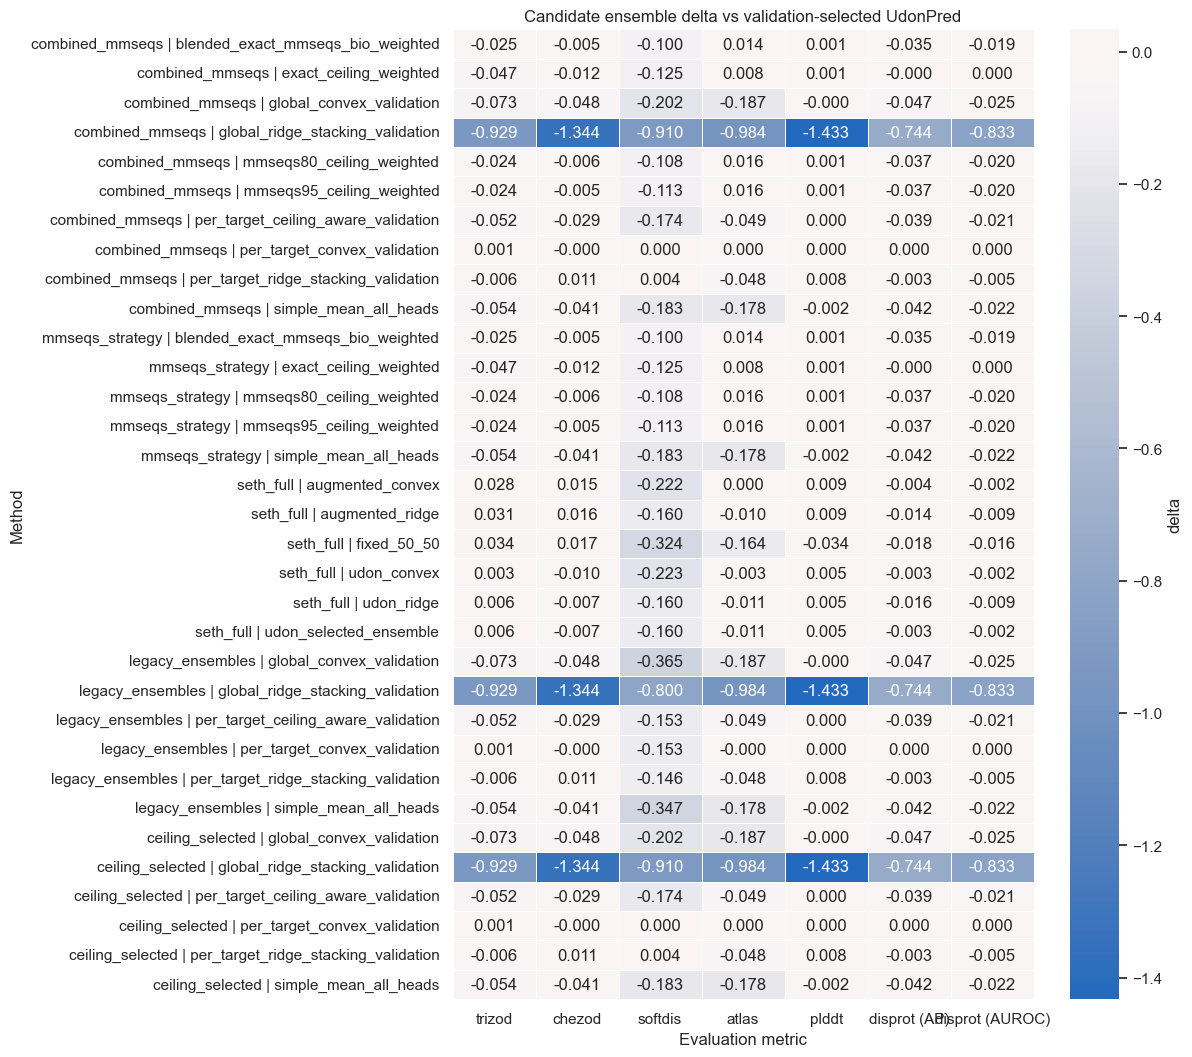

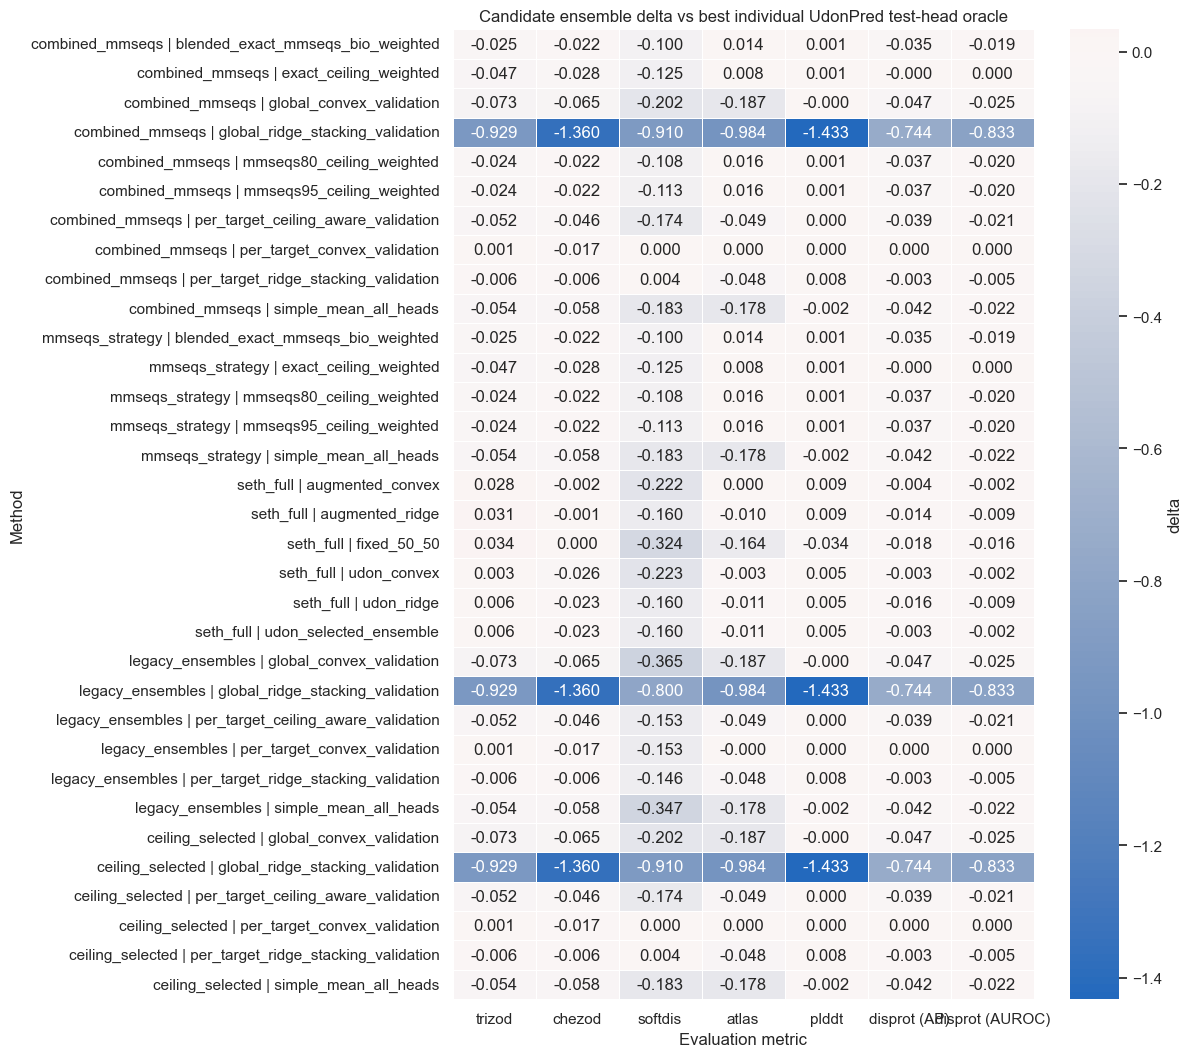

In [9]:
def ordered_metrics(df: pd.DataFrame) -> list[str]:
    return [metric for metric in TARGET_METRICS if metric in set(df["metric"])]

def plot_delta_heatmap(delta_col: str, title: str, filename: str, df: pd.DataFrame = candidate_comparison):
    plot_df = df.copy()
    order = (
        plot_df[["method_family", "source", "method", "method_label"]]
        .drop_duplicates()
        .sort_values(["method_family", "source", "method"])
    )
    pivot = plot_df.pivot_table(index="method_label", columns="metric", values=delta_col, aggfunc="max")
    pivot = pivot.reindex(order["method_label"]).reindex(columns=ordered_metrics(plot_df))
    height = max(6, 0.28 * len(pivot) + 1.5)
    width = max(8, 1.15 * len(pivot.columns) + 4)
    fig, ax = plt.subplots(figsize=(width, height))
    sns.heatmap(
        pivot,
        center=0,
        cmap="vlag",
        annot=True,
        fmt=".3f",
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "delta"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Evaluation metric")
    ax.set_ylabel("Method")
    fig.tight_layout()
    fig.savefig(OUT_DIR / filename, dpi=220, bbox_inches="tight")
    return fig, ax

plot_delta_heatmap(
    "delta_vs_validation_selected",
    "Candidate ensemble delta vs validation-selected UdonPred",
    "delta_vs_validation_selected_heatmap.png",
)
plot_delta_heatmap(
    "delta_vs_best_individual_test_oracle",
    "Candidate ensemble delta vs best individual UdonPred test-head oracle",
    "delta_vs_best_individual_test_oracle_heatmap.png",
)
plt.show()

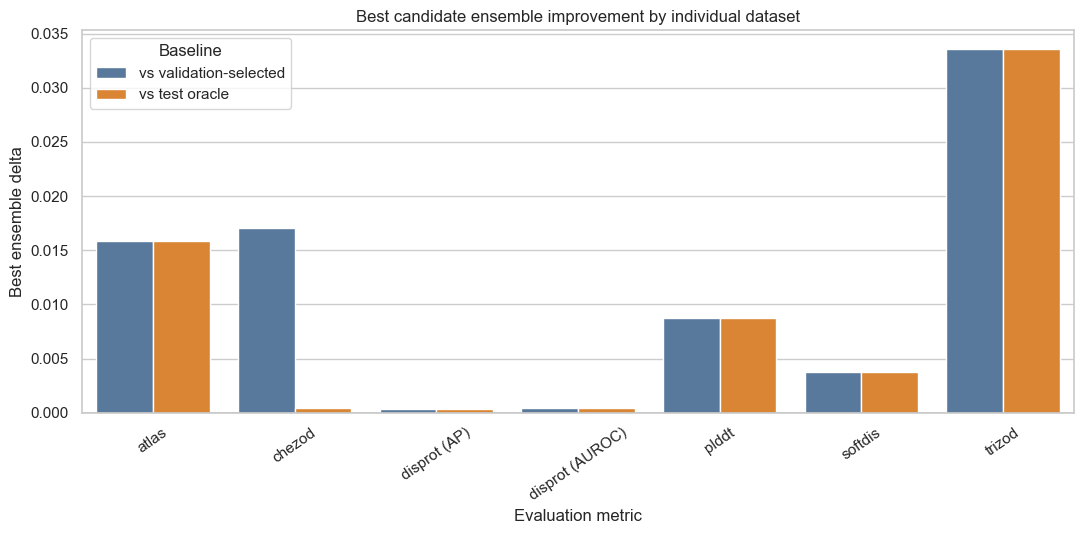

,metric,method_family,source,method,delta_vs_validation_selected,delta_vs_best_individual_test_oracle
49,atlas,MMseqs/ceiling-aware,combined_mmseqs,mmseqs95_ceiling_weighted,0.015880,0.015880
169,chezod,SETH/external-augmented,seth_full,fixed_50_50,0.017048,0.000439
65,disprot (AP),MMseqs/ceiling-aware,combined_mmseqs,per_target_convex_validation,0.000340,0.000340
24,disprot (AUROC),MMseqs/ceiling-aware,combined_mmseqs,exact_ceiling_weighted,0.000453,0.000453
165,plddt,SETH/external-augmented,seth_full,augmented_ridge,0.008751,0.008751
75,softdis,MMseqs/ceiling-aware,combined_mmseqs,per_target_ridge_stacking_validation,0.003784,0.003784
174,trizod,SETH/external-augmented,seth_full,fixed_50_50,0.033607,0.033607


In [10]:
bar_df = best_by_metric.melt(
    id_vars=["metric", "dataset", "method_family", "source", "method"],
    value_vars=["delta_vs_validation_selected", "delta_vs_best_individual_test_oracle"],
    var_name="baseline",
    value_name="delta",
)
bar_df["baseline"] = bar_df["baseline"].map(
    {
        "delta_vs_validation_selected": "vs validation-selected",
        "delta_vs_best_individual_test_oracle": "vs test oracle",
    }
)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=bar_df, x="metric", y="delta", hue="baseline", palette=["#4C78A8", "#F58518"], ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Best candidate ensemble improvement by individual dataset")
ax.set_xlabel("Evaluation metric")
ax.set_ylabel("Best ensemble delta")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Baseline")
fig.tight_layout()
fig.savefig(OUT_DIR / "best_ensemble_delta_by_dataset.png", dpi=220, bbox_inches="tight")
plt.show()

display(best_by_metric[["metric", "method_family", "source", "method", "delta_vs_validation_selected", "delta_vs_best_individual_test_oracle"]])

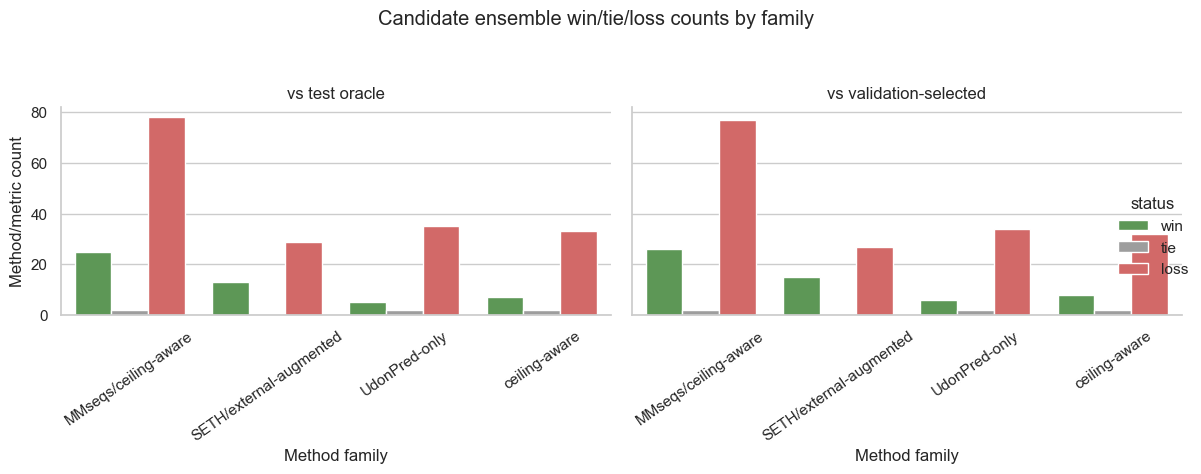

,baseline,method_family,status,count
0,test oracle,MMseqs/ceiling-aware,loss,78
1,test oracle,MMseqs/ceiling-aware,tie,2
2,test oracle,MMseqs/ceiling-aware,win,25
3,test oracle,SETH/external-augmented,loss,29
4,test oracle,SETH/external-augmented,win,13
5,test oracle,UdonPred-only,loss,35
6,test oracle,UdonPred-only,tie,2
7,test oracle,UdonPred-only,win,5
8,test oracle,ceiling-aware,loss,33
9,test oracle,ceiling-aware,tie,2


In [11]:
status_long = candidate_comparison.melt(
    id_vars=["method_family", "source", "method", "metric"],
    value_vars=["vs_validation_selected", "vs_best_individual_test_oracle"],
    var_name="baseline",
    value_name="status",
)
status_long["baseline"] = status_long["baseline"].map(
    {
        "vs_validation_selected": "validation-selected",
        "vs_best_individual_test_oracle": "test oracle",
    }
)
status_counts = (
    status_long.groupby(["baseline", "method_family", "status"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)
status_counts.to_csv(OUT_DIR / "win_loss_counts_by_family.csv", index=False)

g = sns.catplot(
    data=status_counts,
    kind="bar",
    x="method_family",
    y="count",
    hue="status",
    col="baseline",
    order=sorted(status_counts["method_family"].unique()),
    hue_order=["win", "tie", "loss"],
    palette={"win": "#54A24B", "tie": "#9D9D9D", "loss": "#E45756"},
    height=4.5,
    aspect=1.25,
)
g.set_axis_labels("Method family", "Method/metric count")
g.set_titles("vs {col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=35)
g.fig.suptitle("Candidate ensemble win/tie/loss counts by family", y=1.05)
g.fig.tight_layout()
g.fig.savefig(OUT_DIR / "win_loss_summary_by_family.png", dpi=220, bbox_inches="tight")
plt.show()
display(status_counts)

## Focused SETH/external view

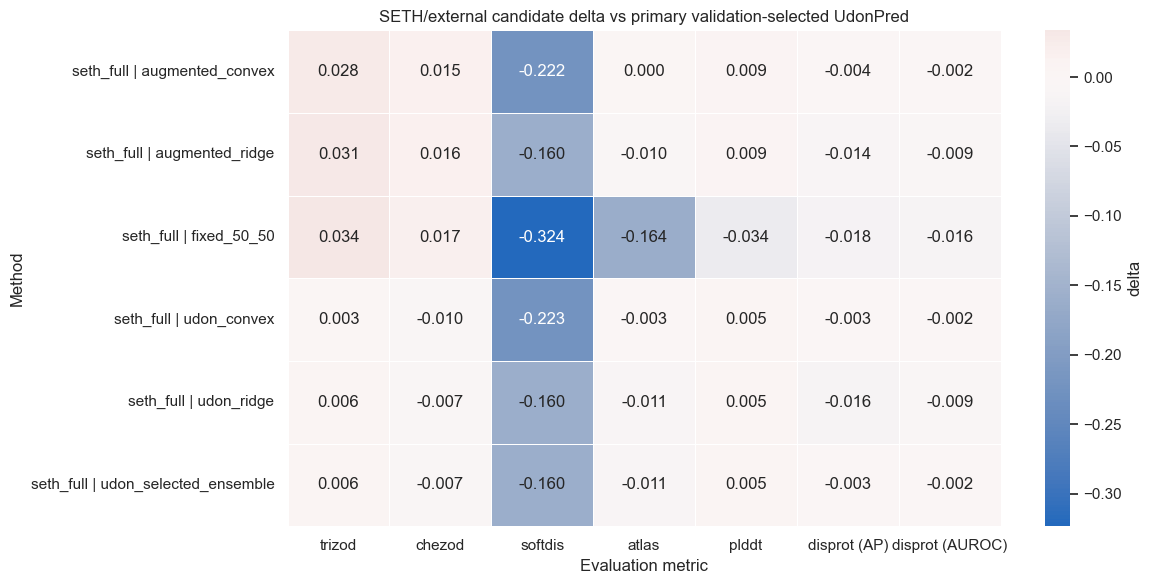

,method,metric,delta_vs_udon_selected_in_seth_notebook
0,augmented_convex,trizod,0.024899
1,augmented_ridge,trizod,0.024965
2,fixed_50_50,trizod,0.027348
3,augmented_convex,chezod,0.024797
4,augmented_ridge,chezod,0.022707
5,fixed_50_50,chezod,0.023839
6,augmented_convex,softdis,0.000320
7,augmented_ridge,softdis,0.000403
8,fixed_50_50,softdis,-0.163097
9,augmented_convex,atlas,0.003128


In [12]:
seth_candidates = candidate_comparison[candidate_comparison["source"].eq("seth_full")].copy()
if seth_candidates.empty:
    print("No SETH/external candidate rows available.")
else:
    plot_delta_heatmap(
        "delta_vs_validation_selected",
        "SETH/external candidate delta vs primary validation-selected UdonPred",
        "seth_external_delta_vs_validation_selected_heatmap.png",
        df=seth_candidates,
    )
    plt.show()

seth_delta_path = INPUTS["seth_delta_matrix"]
if seth_delta_path.exists():
    seth_delta = pd.read_csv(seth_delta_path)
    seth_delta = normalize_matrix_columns(seth_delta)
    if "scenario" in seth_delta.columns:
        seth_delta = seth_delta[seth_delta["scenario"].eq("full")].copy()
    if "augmented_method" in seth_delta.columns:
        seth_delta = seth_delta.rename(columns={"augmented_method": "method"})
    seth_delta = seth_delta[~seth_delta.get("method", pd.Series(dtype=str)).astype(str).str.lower().eq("pdbflex")].copy()
    seth_delta_cols = [column for column in TARGET_METRICS if column in seth_delta.columns]
    if seth_delta_cols:
        focused = seth_delta.melt(id_vars=["method"], value_vars=seth_delta_cols, var_name="metric", value_name="delta_vs_udon_selected_in_seth_notebook")
        focused = focused[focused["metric"].isin(TARGET_METRICS)].copy()
        focused.to_csv(OUT_DIR / "seth_external_source_delta_matrix_long.csv", index=False)
        display(focused)
    else:
        print("SETH delta matrix exists but contains no recognized target metric columns.")

## Source-local sanity check

For sampled rows, recompute deltas from the saved tidy table and assert that they match the stored columns.

In [13]:
sample = comparison.sample(min(20, len(comparison)), random_state=7).copy()
recomputed_validation_delta = sample["score"] - sample["validation_selected_score"]
recomputed_oracle_delta = sample["score"] - sample["best_individual_test_oracle_score"]
assert np.allclose(recomputed_validation_delta, sample["delta_vs_validation_selected"], equal_nan=True)
assert np.allclose(recomputed_oracle_delta, sample["delta_vs_best_individual_test_oracle"], equal_nan=True)
assert "pdbflex" not in set(comparison["dataset"])
assert "pdbflex" not in set(individual_heads["method"].str.lower())

print("Sanity checks passed.")
print(f"Saved tables and figures under: {OUT_DIR.relative_to(ROOT)}")

Sanity checks passed.
Saved tables and figures under: results\ensembles_individual
